# Exercise 5.1: The Volumes of Hyperspheres

An $n$-dimensional sphere ($n$-sphere), also known as an $n$-ball, is the region of space comprising all points within a fixed distance, called the radius, from a given point. 

In this example we wish to calculate the volume of an $n$-ball with unit radius, centered at the origin, for various values of $n$. 

For $n=0$ dimensions, the volume is defined to be $V_0 = 1$. In one dimension, the volume is simply $V_1 = 2$. 

To calculate the volumes in higher dimensions, we will use the Monte Carlo integration technique, generalizing the formula we used to obtain an approximation to $\pi$: 


$V_n = \int \mathrm{d}^n x ~\theta(1 - \sum_{i=1}^n x_i^2)$,

so for example, the volume of a 2-ball (a circle) is simply:

$V_2 = 4 \int_{0}^1 \mathrm{d} x_1 \int_{0}^1 \mathrm{d} x_2  ~\theta(1 - x_1^2 - x_2^2)$.

We expect this to be = $\pi$! The procedure to obtain this result was examined in Example 5.4. We will generalize this to $n$ dimensions. 

(a) Start by calculating the volume of an $3$-dimensional sphere, for which we expect the result $V_3 = \frac{4}{3} \pi$: 

$V_3 = 2^3 \int_{0}^1 \mathrm{d} x_1 \int_{0}^1 \mathrm{d} x_2 \int_{0}^1 \mathrm{d} x_3  ~\theta(1 - x_1^2 - x_2^2 - x_3^2)$.


(b) Generalize your code to handle any number of dimensions, and calculate the volumes of $n$-balls up to $n=30$ using:

$V_n = 2^n \int_{0}^1 \mathrm{d} x_1 \int_{0}^1 \mathrm{d} x_2 \int_{0}^1 ... \mathrm{d} x_n ~\theta(1 - \sum_{i=1}^n x_i^2)$. 

(c) Graph the result. 

(d) Add the analytical results to your graph, given for the unit sphere, by:

$V_n = \frac{\pi^{n/2}}{\Gamma(\frac{n}{2}+1)}$, where $\Gamma$ is the Euler Gamma function. 

You may use the scipy special function: 

```scipy.special.gamma``` which represents the $\Gamma$ function.

CHALLENGE PROBLEM: For a large enough number of dimensions, the volume of the unit sphere drops dramatically, making it extremely difficult to get an estimate of the volume of the sphere. Use importance sampling to bypass this problem. Plot the comparison up to $n=30$ with the associated error and show that it converges to the expected analytical solution. Plot your results in log scale and include a ratio panel. 

Hint: Use $w(r) = A \exp(-\alpha r^2)$, where $r$ is the distance from the origin, defined in the hypercube. This factorizes:

$w(r) = A \exp(-\alpha x_1^2) \exp(-a x_2^2) \ldots \exp(-\alpha x_n^2)$, which allows us to fix the normalization constant easily in $n$-dimensions:

$\int_V \mathrm{d} V w(r) = A \left( \int_0^1 \exp(-\alpha x^2) \mathrm{d}x \right)^n = 1$.

This can be a separate integration step. 

We can sample each component of the vector $\vec{x}$ independently, with probability:

$p(x_i) = \exp(-\alpha x_i^2)$ 

to get $\vec{x} = (x_1, x_2, \ldots, x_n)$, via von Neumann rejection. 

In practice, $\alpha \sim n/2$ is a reasonable starting point. This can allow you to go up to $n=30$ easily. Try this out with $10^6$ integration points. 

Solution:

(a) Let's start by extending Example 5.4 to handle three-dimensional spheres. This is trivially obtained by adding an extra dimension to the calculation. 

In [4]:
import math
import numpy as np
import random

# The number of points to use:
N=1E6

def mcint_3D(func,limitsx,limitsy,limitsz, N):
    """Calculates the three-dimensional Monte Carlo integral of func in limitsx=[a_x,b_x] and limitsy=[a_y,b_y], limitsz=[a_z, b_z], for N points"""
    sumf = 0 # we will use this variable for the sum of f(x_i)
    sumfsq = 0 # and this one for the sum of f(x_i)^2, used in the error calculation
    for i in range(int(N)):
        xi = (limitsx[1]-limitsx[0]) * random.random() + limitsx[0]
        yi = (limitsy[1]-limitsy[0]) * random.random() + limitsy[0]
        zi = (limitsz[1]-limitsz[0]) * random.random() + limitsz[0]
        fxv = func(xi,yi,zi) # evaluate only once
        sumf = sumf + fxv
        sumfsq = sumfsq + fxv**2
    # now calculate the average value of f (i.e. the integral):
    I = sumf/N
    # and the error: 
    sigmaIsq = (1/N) * ( (1/N) * sumfsq - I**2 ) # this is the variance (i.e. the error squared)
    sigmaI = math.sqrt(sigmaIsq) # this is the actual error
    return I, sigmaI # return the integral and its error 

# now define the function to be integrated as the theta function: 
def f(x,y,z):
    if x**2 + y**2 + z**2 > 1: # outside the sphere
        return 0
    else:
        return 1 # inside the sphere


# let's first calculate the integral:
Int_3D, Err_3D = mcint_3D(f,[0,1],[0,1], [0,1],N) # this way you can access both the integral and its error

# print: 
print("V_3 estimate for N=", N, 'is', 8*Int_3D, '+-', 8*Err_3D)
print("Compared to the expected value=", 4/3 * math.pi)

V_3 estimate for N= 1000000.0 is 4.18936 +- 0.0039955153347722245
Compared to the expected value= 4.1887902047863905


(b) Now let's generalize the integration formula to $n$ dimensions!

In [5]:
def MCVolume_nBall(n,N): 
    """Calculates the volume of an n-ball -- a sphere in n-dimensions, using Monte Carlo integration"""
    # each time we go through the loop, we create a list of random numbers of length n
    sumf = 0 # we will use this variable for the sum of f(x_i)
    for i in range(int(N)):
        sumxisq = 0
        for j in range(int(n)):
            sumxisq = sumxisq + random.random()**2
        # at this point sumxisq is the sum of the squares of random numbers
        # to implement the theta function we sum over the list and square:
        if sumxisq < 1:
            sumf = sumf + 1
    # now calculate the average value of f (i.e. the integral):
    I = sumf/N    
    sigmaIsq = (1/N) * ( (1/N) * sumf - I**2 ) # this is the variance (i.e. the error squared)
    sigmaI = math.sqrt(sigmaIsq) # this is the actual error
    # the volume is actually 2^n times the integral: 
    Volume = 2**n * I
    Error = 2**n * sigmaI
    return Volume, Error    

# Let's test it for n=1,2,3:
V1, errV1 = MCVolume_nBall(1,1E6)
print("V1=",V1,"+-",errV1)
V2, errV2 = MCVolume_nBall(2,1E6)
print("V2=",V2,"+-",errV2)
V3, errV3 = MCVolume_nBall(3,1E6)
print("V3=",V3,"+-",errV3)

V1= 2.0 +- 0.0
V3= 3.140904 +- 0.0016426618832809142
V3= 4.186368 +- 0.003995656012293351


(c) It works! Now let's see do this for n=1 to n=30 and make a graph!

In [6]:
from tqdm import tqdm

# the number of dimensions
narray = np.linspace(1,30,30)

# the number of points to integrate over:
N = 1E6

# perform the calculations
Vnarray = []
Errnarray = []
for n in tqdm(narray):
    Vn, errVn = MCVolume_nBall(n,N)
    Vnarray.append(Vn) # append to the array
    Errnarray.append(errVn) # also append the error

100%|███████████████████████████████████████████████████| 30/30 [00:55<00:00,  1.84s/it]


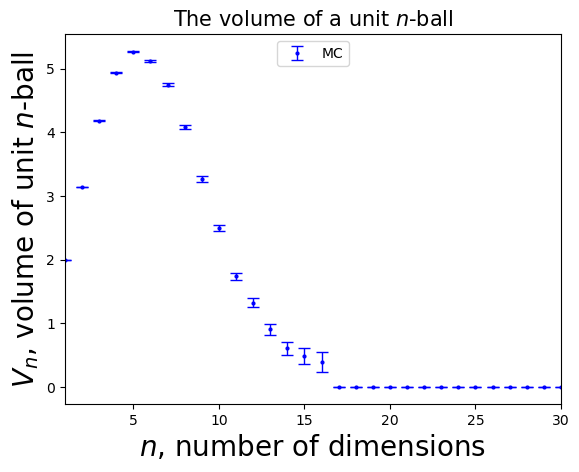

In [7]:
# and now plot!
import matplotlib.pyplot as plt # import matplotlib, a conventional module name is plt
import numpy as np

fig, ax = plt.subplots() # create the elements required for matplotlib. This creates a figure containing a single axes.

# set the labels and titles:
ax.set_xlabel(r'$n$, number of dimensions', fontsize=20) # set the x label
ax.set_ylabel(r'$V_n$, volume of unit $n$-ball', fontsize=20) # set the y label
ax.set_title('The volume of a unit $n$-ball', fontsize=15) # set the title 

# set the x and y limits:
ax.set_xlim(1, 30)

# plot with error bars:
ax.errorbar(narray, Vnarray, yerr=Errnarray, color='blue', lw=0, fmt='o', elinewidth=1,capsize=4, ms=2, label="MC") 

# construct the legend:
ax.legend(loc='upper center')  # Add a legend

plt.show() # show the plot here

We can observe that the volume of the unit $n$-ball increases until $n=4$ and then decreases, dropping to almost zero at around $n\sim 15-20$!

(d) Now let's calculate the analytical result using ```scipy.special.gamma``` and the formula given above and plot it along with the MC results:

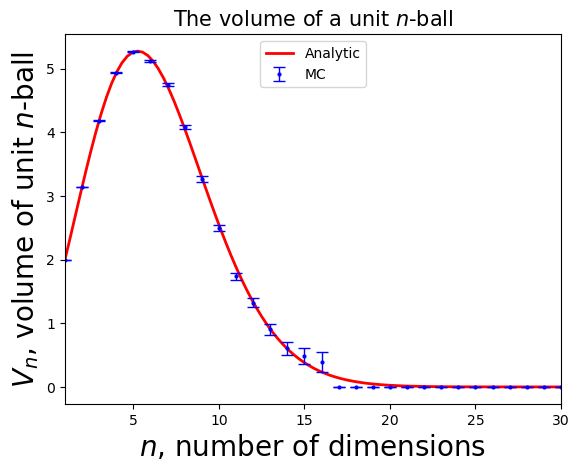

In [8]:
import scipy
import matplotlib.pyplot as plt # import matplotlib, a conventional module name is plt
import numpy as np

# get the analytic result: 
narrayA = np.linspace(1,31,100)
VnAnalytic = np.pi**(narrayA/2)/scipy.special.gamma(narrayA/2+1)

fig, ax = plt.subplots() # create the elements required for matplotlib. This creates a figure containing a single axes.

# set the labels and titles:
ax.set_xlabel(r'$n$, number of dimensions', fontsize=20) # set the x label
ax.set_ylabel(r'$V_n$, volume of unit $n$-ball', fontsize=20) # set the y label
ax.set_title('The volume of a unit $n$-ball', fontsize=15) # set the title 

# set the x and y limits:
ax.set_xlim(1, 30)

# plot analytic result: 
ax.plot(narrayA, VnAnalytic, color='red', linestyle='-', lw=2, label="Analytic") 

# plot MC result:
ax.errorbar(narray, Vnarray, yerr=Errnarray, color='blue', lw=0, fmt='o', elinewidth=1,capsize=4, ms=2, label="MC") 

# construct the legend:
ax.legend(loc='upper center')  # Add a legend

plt.show() # show the plot here


Challenge problem: Let's use importance sampling to improve the results! We wish to sample more points closer to the origin. We will try $w(r) = A \exp(-\alpha r^2)$, with $r$ the distance from the origin. Essentially what this means is that we are no longer choosing points uniformly inside the cube: we are now putting more points near $r=0$. 

In [9]:
def weight(x, alpha=2): 
    """The weight function that corresponds to the importance sampling"""
    # x is the vector, r is the distance from the origin
    rsq = np.sum(np.square(x))
    return np.exp(-alpha * rsq)  

def sample_coordinate(alpha):
    """Sample one coordinate x in [0,1] from p(x) ∝ exp(-alpha x^2)."""
    while True:
        x = random.random()
        if random.random() < math.exp(-alpha * x * x):
            return x


def MCVolume_nBall_IS(n,N, weight, alpha=3): 
    """Calculates the volume of an n-ball -- a sphere in n-dimensions, using Monte Carlo integration"""
    # each time we go through the loop, we create a list of random numbers of length n
    ngen = 0
    # the first step is to find the normalizsation of the weight function numerically:
    # here, we use the same number of points as for the volume calculation:
    # note that the 1D integral raised to the n-th power is the same as the n-dim integral
    weightsum = 0
    for i in range(int(N)):
        x = random.random()
        weightsum += weight(x,alpha=alpha)
    weightint = (weightsum/N)**n
    
    sumf = 0 # we will use this variable for the sum of f(x_i)
    sumfsq = 0 # use this for the squares
    for j in range(int(N)):
        x = np.zeros(int(n))
        for i in range(int(n)):
            x[i] = sample_coordinate(alpha)
        # get the weight:
        w = weight(x,alpha=alpha)
        # at this point sumxisq is the sum of the squares of random numbers
        # to implement the theta function we sum over the list and square:
        sumxisq = np.sum(np.square(x))
        if sumxisq < 1: # now implement the function
            sumf += weightint/w # multiply by weight function, but NORMALIZED
            sumfsq += (weightint/w)**2

    # now calculate the average value of f (i.e. the integral):
    I = sumf/N    
    sigmaI = 0
    sigmaIsq = (1/N) * ( (1/N) * sumfsq - I**2 ) # this is the variance (i.e. the error squared)
    sigmaI = math.sqrt(sigmaIsq) # this is the actual error
    # the volume is actually 2^n times the integral: 
    Volume = 2**n * I
    Error = 2**n * sigmaI
    return Volume, Error    

# Let's test it for n=1,2,3:
Nint = 100000
V1, errV1 = MCVolume_nBall_IS(1,Nint, weight)
print("V1=",V1,"+-",errV1)
V2, errV2 = MCVolume_nBall_IS(2,Nint, weight)
print("V3=",V2,"+-",errV2)
V3, errV3 = MCVolume_nBall_IS(3,Nint, weight)
print("V3=",V3,"+-",errV3)

V1= 2.0055675980004732 +- 0.0067071025736470434
V3= 3.1433799088240595 +- 0.010275440851898953
V3= 4.218784235439519 +- 0.01291847040518225


It works! now let's recalculate up to high $n$. Note that this takes O(10 min) to ruin! 

In [ ]:
from tqdm import tqdm
import numpy as np

# the number of dimensions
narray = np.linspace(1,30,30)

# the number of points to integrate over:
N=1E6 # points for regular integration 
# perform the calculations
Vnarray = []
Errnarray = []
for n in tqdm(narray):
    if n > 5: # new importance sampling only kicks in for n>10:
        Vn, errVn = MCVolume_nBall_IS(n,N, weight,alpha=n/2)
    else:
        Vn, errVn = MCVolume_nBall(n,N)
    Vnarray.append(Vn) # append to the array
    Errnarray.append(errVn) # also append the error

 17%|████████▋                                           | 5/30 [00:02<00:14,  1.73it/s]

In [ ]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator

# get the analytic result on a dense grid for the top panel
narrayA = np.linspace(1, 31, 100)
VnAnalytic = np.pi**(narrayA/2) / scipy.special.gamma(narrayA/2 + 1)

# analytic result evaluated at the MC points for the ratio
VnAnalytic_MC = np.pi**(narray/2) / scipy.special.gamma(narray/2 + 1)

# ratio and its error
ratio = Vnarray / VnAnalytic_MC
ratio_err = Errnarray / VnAnalytic_MC

# make two panels
fig, (ax, axr) = plt.subplots(2, 1,
    sharex=True,
    figsize=(8, 8),
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
)

# top panel
ax.set_ylabel(r'$V_n$, volume of unit $n$-ball', fontsize=20)
ax.set_title('The volume of a unit $n$-ball', fontsize=15)
ax.set_xlim(1, 30)
ax.set_yscale('log')

ax.plot(narrayA, VnAnalytic, color='red', linestyle='-', lw=2, label="Analytic")

ax.errorbar(narray, Vnarray, yerr=Errnarray,color='blue', lw=0, fmt='o', elinewidth=1, capsize=4, ms=2, label="MC")

ax.legend(loc='upper center')
ax.tick_params(axis='both', labelsize=12)

# ratio panel
axr.errorbar(narray, ratio, yerr=ratio_err,color='blue', lw=0, fmt='o',elinewidth=1, capsize=4, ms=2)

axr.axhline(1.0, color='black', linestyle='--', lw=1)

axr.set_xlabel(r'$n$, number of dimensions', fontsize=20)
axr.set_ylabel('MC / Ana.', fontsize=14)
axr.set_xlim(1, 31)
axr.set_ylim(0.95, 1.05)   # adjust if needed
axr.tick_params(axis='both', labelsize=12)
# minor ticks
axr.yaxis.set_minor_locator(AutoMinorLocator())
axr.xaxis.set_minor_locator(AutoMinorLocator())

plt.show()

As you can see, we now have percent-level precision up to $n=30$, with reasonable run time!

AI/LLM Use Statement: No AI/LLM assistance was used. 